# Occupation Distribution -- Donut Charts

This notebook produces donut charts showing the top-20 occupation distribution
across individuals in the dataset, split four ways:

- **Before 1900** -- all individuals whose impact year precedes 1900
- **After 1900** -- all individuals whose impact year is 1900 or later
- **Roman Empire** -- individuals mapped to the Roman Empire polity
- **Tang Dynasty** -- individuals mapped to the Tang Dynasty polity

In [ ]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.duckdb"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


## Setup

In [ ]:
import duckdb
import polars as pl
import matplotlib.pyplot as plt
DB = DB_PATH
conn = duckdb.connect(DB, read_only=True)


## Load individuals with occupations and impact dates

We join `individuals` with `individuals_impact_date` and parse the impact year
from the date string, keeping only rows that have a non-empty occupation field.

In [ ]:
query = """
    SELECT 
        i.wikidata_id,
        i.occupations_en,
        id.floruit_period_start
    FROM individuals i
    JOIN individuals_floruit_period id ON i.wikidata_id = id.wikidata_id
    WHERE i.occupations_en IS NOT NULL AND i.occupations_en != ''
"""

df = conn.execute(query).pl()
print(f"Total individuals with occupations and impact dates: {len(df):,}")

In [4]:
print(f"Loaded {len(df):,} individuals with occupations and impact dates")
df.head(20)

Loaded 9,032,161 individuals with occupations and impact dates


wikidata_id,occupations_en,floruit_period_start
str,str,i64
"""Q10000001""","""ballet dancer""",1967
"""Q1000002""","""journalist; playwright; screen…",1962
"""Q10000029""","""military officer""",null
"""Q1000005""","""prose writer; journalist; play…",1890
"""Q1000006""","""film director; screenwriter; f…",2001
…,…,…
"""Q1000023""","""judge; jurist""",1942
"""Q1000026""","""curator""",1958
"""Q1000034""","""university teacher; mathematic…",1848


## Explode semicolon-separated occupations into individual rows

Each individual may list multiple occupations separated by `; `.
We split these into separate rows so every occupation is counted independently.

In [5]:
df_exploded = (
    df
    .with_columns(
        pl.col('occupations_en').str.split('; ').alias('occupation_list')
    )
    .explode('occupation_list')
    .rename({'occupation_list': 'occupation'})
    .filter(pl.col('occupation').is_not_null() & (pl.col('occupation') != ''))
)

print(f"Total occupation entries: {len(df_exploded):,}")

Total occupation entries: 12,653,535


## Split by period: before 1900 and 1900 onward

In [6]:
df_before_1900 = df_exploded.filter(pl.col('floruit_period_start') < 1900)
df_after_1900 = df_exploded.filter(pl.col('floruit_period_start') >= 1900)

print(f"Occupation entries before 1900: {len(df_before_1900):,}")
print(f"Occupation entries 1900+: {len(df_after_1900):,}")

Occupation entries before 1900: 1,598,013
Occupation entries 1900+: 6,903,594


## Helper: top-N occupations with an "Others" residual

Returns labels, sizes, total count, and the percentage covered by the top N.

In [7]:
def get_top_occupations_with_others(df_period, n_top=20):
    """Get top N occupations and group the rest as Others."""
    occ_counts = (
        df_period
        .group_by('occupation')
        .agg(pl.len().alias('count'))
        .sort('count', descending=True)
    )
    total = occ_counts['count'].sum()

    top = occ_counts.head(n_top)
    top_total = top['count'].sum()
    others_count = total - top_total

    labels = top['occupation'].to_list() + ['Others']
    sizes = top['count'].to_list() + [others_count]

    top_pct = top_total / total * 100
    return labels, sizes, total, top_pct

labels_before, sizes_before, total_before, pct_before = get_top_occupations_with_others(df_before_1900)
labels_after, sizes_after, total_after, pct_after = get_top_occupations_with_others(df_after_1900)

print(f"Before 1900: top 20 cover {pct_before:.1f}% of {total_before:,} entries")
print(f"After 1900: top 20 cover {pct_after:.1f}% of {total_after:,} entries")

Before 1900: top 20 cover 46.7% of 1,598,013 entries
After 1900: top 20 cover 40.5% of 6,903,594 entries


## Donut chart helper

Renders a single donut chart with greyscale colouring. Labels with less than
2% share are suppressed to keep the chart readable.

In [8]:
OCCUPATION_COLORS = {}  # will be populated after all labels are known


def draw_donut(labels, sizes, center_label, n_individuals=None):
    colors = [OCCUPATION_COLORS.get(l, '#aaaaaa') for l in labels]

    fig, ax = plt.subplots(figsize=(12, 12))

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
        pctdistance=0.75,
        startangle=90,
        wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.5)
    )

    for text in texts:
        text.set_fontsize(14)
        text.set_color('#333')
        text.set_fontweight('bold')

    for autotext in autotexts:
        autotext.set_fontsize(13)
        autotext.set_color('#333')
        autotext.set_fontweight('bold')

    if n_individuals is not None:
        ax.text(0, 0.05, center_label,
                ha='center', va='center', fontsize=22, color='#333', fontweight='bold')
        ax.text(0, -0.05, f'n = {n_individuals:,}',
                ha='center', va='center', fontsize=16, color='#888', fontweight='bold')
    else:
        ax.text(0, 0, center_label,
                ha='center', va='center', fontsize=22, color='#333', fontweight='bold')

    plt.tight_layout()
    plt.show()

## Donut chart -- Before 1900

In [9]:
# Drawing deferred until after colour map is built
pass

## Donut chart -- After 1900

In [10]:
# Drawing deferred until after colour map is built
pass

## Load polity-specific data: Roman Empire and Tang Dynasty

We query `individuals_cliopatria` for individuals mapped to each polity and
join back to get their occupations.

In [ ]:
polity_query = """
    SELECT 
        ic.wikidata_id,
        i.occupations_en,
        ic.floruit_period_start as floruit_period_start,
        ic.polity_name
    FROM individuals_cliopatria ic
    JOIN individuals i ON ic.wikidata_id = i.wikidata_id
    WHERE (ic.polity_name LIKE '%Roman Empire%' OR ic.polity_name LIKE '%Tang Dynasty%')
      AND i.occupations_en IS NOT NULL AND i.occupations_en != ''
"""

df_polities = conn.execute(polity_query).pl()

# polity_name is a `;`-separated list when an individual sits in several polities,
# so match on substring rather than equality.
df_roman = df_polities.filter(pl.col('polity_name').str.contains('Roman Empire'))
df_tang = df_polities.filter(pl.col('polity_name').str.contains('Tang Dynasty'))

print(f"Roman Empire individuals with occupations: {len(df_roman):,}")
print(f"Tang Dynasty individuals with occupations: {len(df_tang):,}")

In [12]:
print("Roman Empire sample:")
display(df_roman.head(10))
print("\nTang Dynasty sample:")
display(df_tang.head(10))

Roman Empire sample:


wikidata_id,occupations_en,floruit_period_start,polity_name
str,str,i64,str
"""Q1000155""","""Catholic priest; Catholic bish…",1247,"""Personal union of Holy Roman E…"
"""Q1000194""","""Catholic priest; Catholic bish…",1162,"""Holy Roman Empire"""
"""Q100029""","""writer; military personnel; po…",1752,"""Holy Roman Empire Minor States…"
"""Q100031""","""writer; poet""",1662,"""Holy Roman Empire Minor States…"
"""Q1000323""","""jurist; playwright""",1778,"""Holy Roman Empire Minor States…"
"""Q1000581""","""military historian; non-fictio…",1773,"""Holy Roman Empire Minor States…"
"""Q1001132""","""politician""",1402,"""Allegiance of Swiss Confederat…"
"""Q100116""","""printmaker; copper engraver; e…",1698,"""Holy Roman Empire Minor States…"
"""Q100134""","""composer""",1659,"""Holy Roman Empire Minor States…"



Tang Dynasty sample:


wikidata_id,occupations_en,floruit_period_start,polity_name
str,str,i64,str
"""Q1005372""","""military leader""",613,"""Tang Dynasty;Sui Dynasty"""
"""Q10086413""","""politician""",null,"""Tang Dynasty"""
"""Q10112313""","""painter""",851,"""Five Dynasties and Ten Kingdom…"
"""Q10125021""","""military personnel""",null,"""Tang Dynasty"""
"""Q10125738""","""military personnel""",801,"""Tang Dynasty"""
"""Q10127297""","""writer; poet""",726,"""Tang Dynasty"""
"""Q1013023""","""poet; Buddhist monk""",643,"""Tang Dynasty"""
"""Q10144704""","""politician""",null,"""Tang Dynasty"""
"""Q1017968""","""poet; politician""",618,"""Tang Dynasty;Sui Dynasty"""


## Explode occupations for each polity and compute top-N

In [13]:
def explode_occupations(df_pol):
    return (
        df_pol
        .with_columns(
            pl.col('occupations_en').str.split('; ').alias('occupation_list')
        )
        .explode('occupation_list')
        .rename({'occupation_list': 'occupation'})
        .filter(pl.col('occupation').is_not_null() & (pl.col('occupation') != ''))
    )

df_roman_exp = explode_occupations(df_roman)
df_tang_exp = explode_occupations(df_tang)

labels_roman, sizes_roman, total_roman, pct_roman = get_top_occupations_with_others(df_roman_exp)
labels_tang, sizes_tang, total_tang, pct_tang = get_top_occupations_with_others(df_tang_exp, n_top=10)

print(f"Roman Empire: top 20 cover {pct_roman:.1f}% of {total_roman:,} occupation entries")
print(f"Tang Dynasty: top 20 cover {pct_tang:.1f}% of {total_tang:,} occupation entries")

Roman Empire: top 20 cover 50.9% of 83,138 occupation entries
Tang Dynasty: top 20 cover 92.6% of 5,393 occupation entries


In [14]:
# Build unified colour map across all four sunbursts
all_labels_union = list(dict.fromkeys(
    labels_before + labels_after + labels_roman + labels_tang
))
all_labels_union = [l for l in all_labels_union if l != 'Others']

_tab20 = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors
OCCUPATION_COLORS.update({occ: _tab20[i % len(_tab20)] for i, occ in enumerate(all_labels_union)})
OCCUPATION_COLORS['Others'] = '#d0d0d0'

print(f'Assigned colours to {len(all_labels_union)} occupations (+ Others in grey)')

Assigned colours to 36 occupations (+ Others in grey)


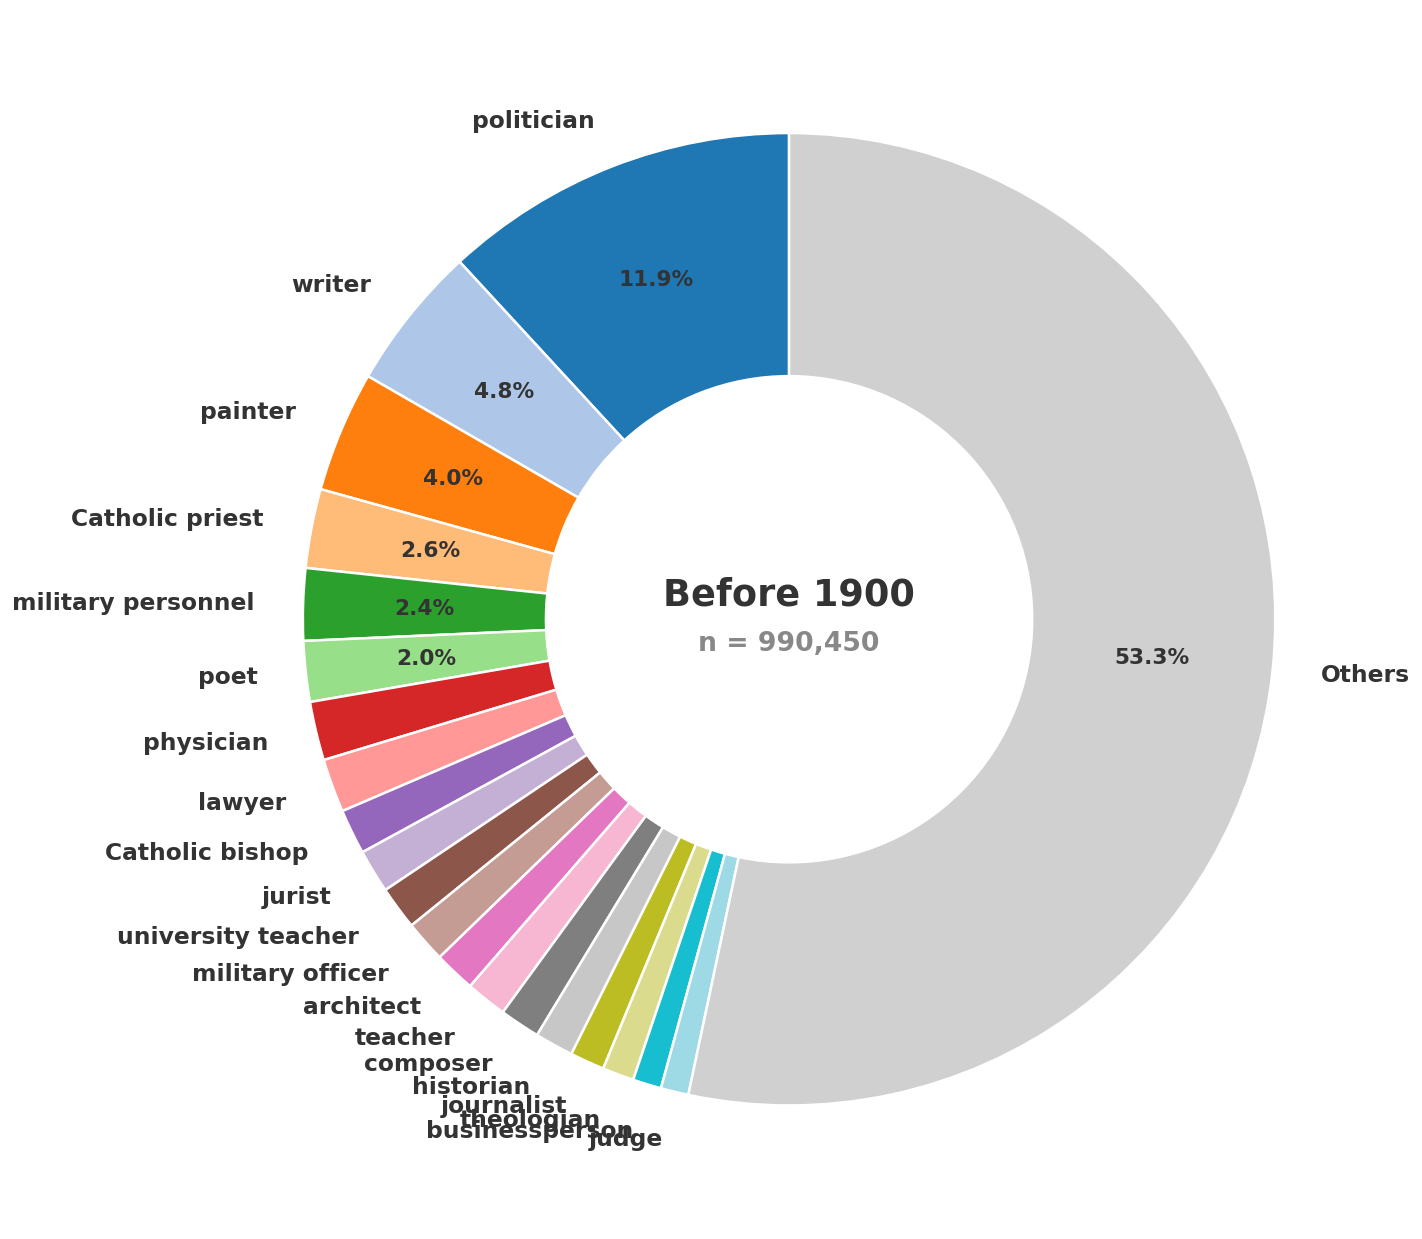

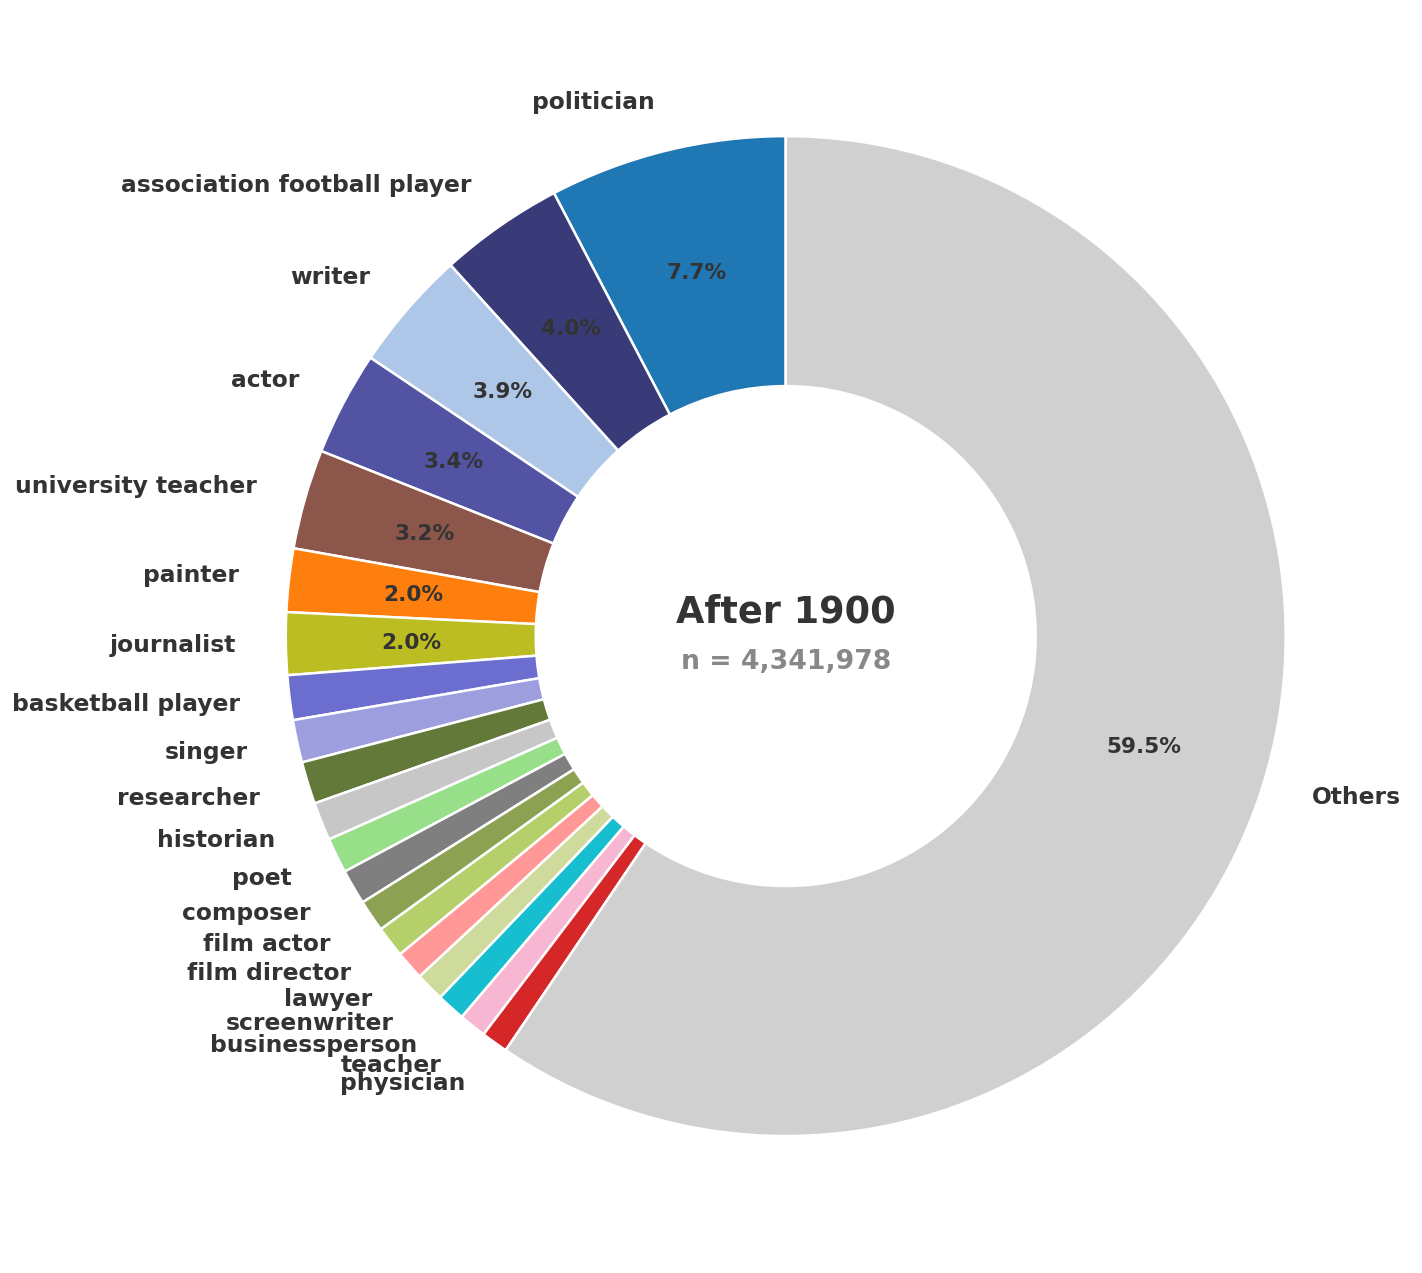

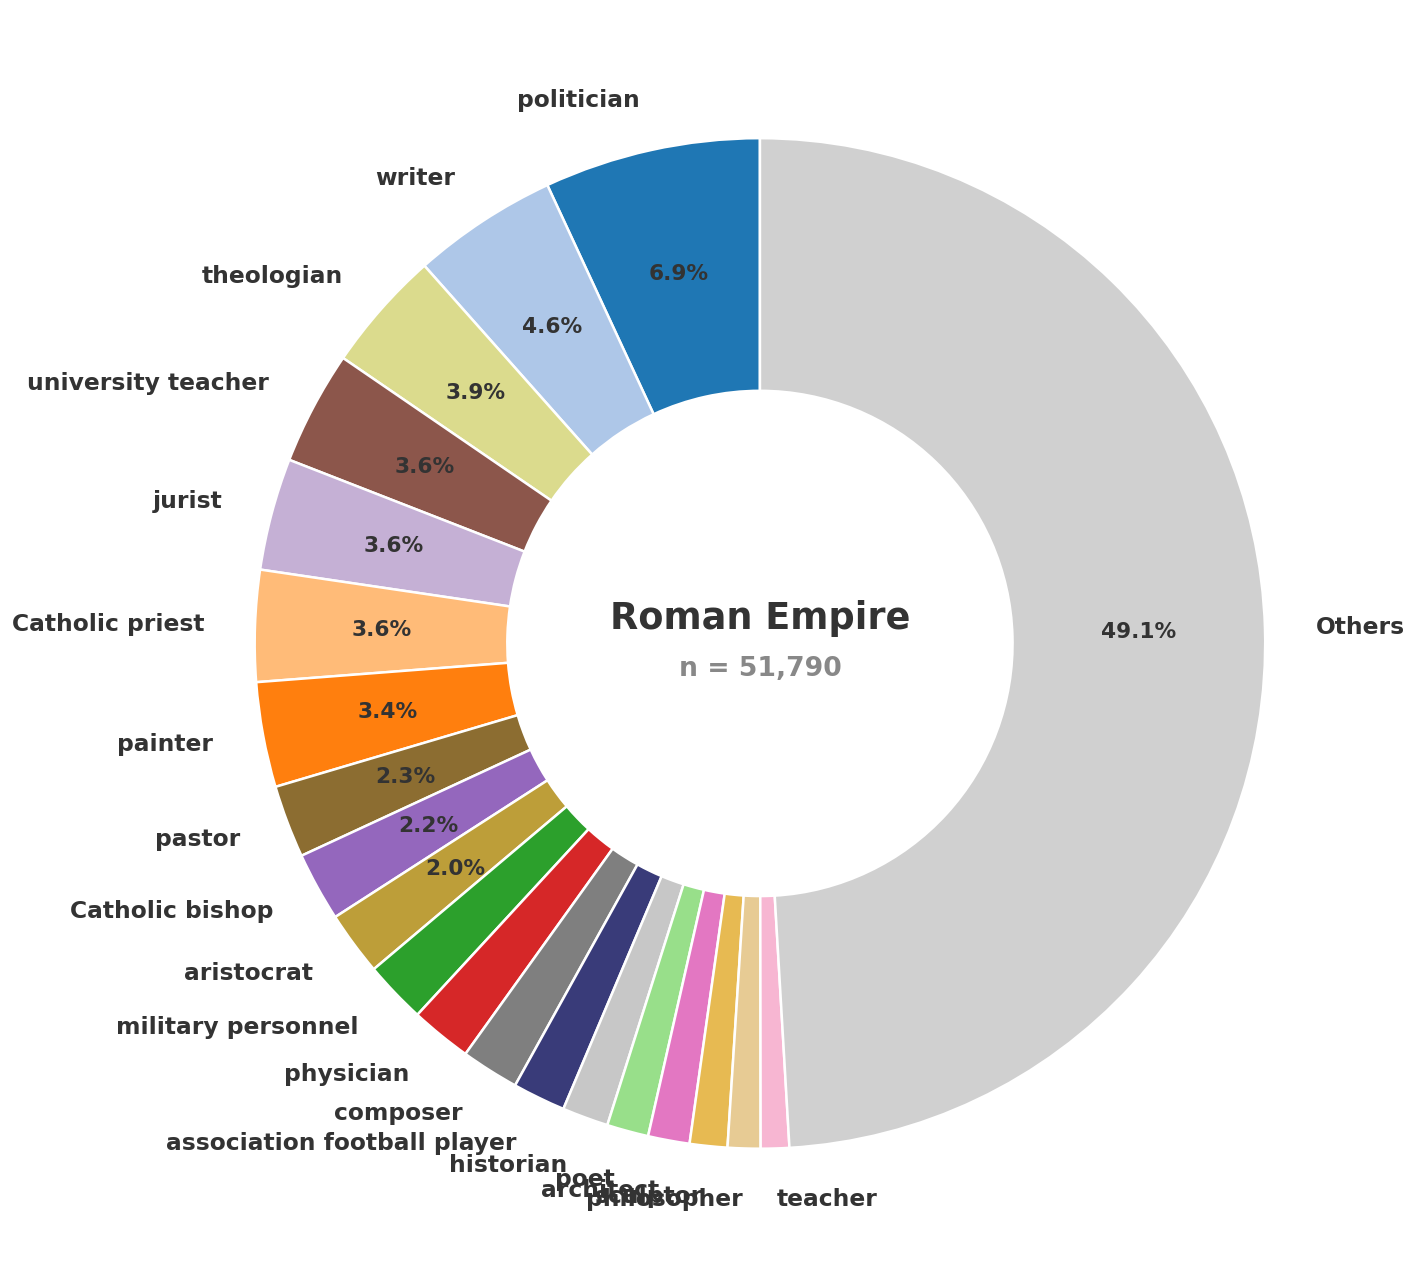

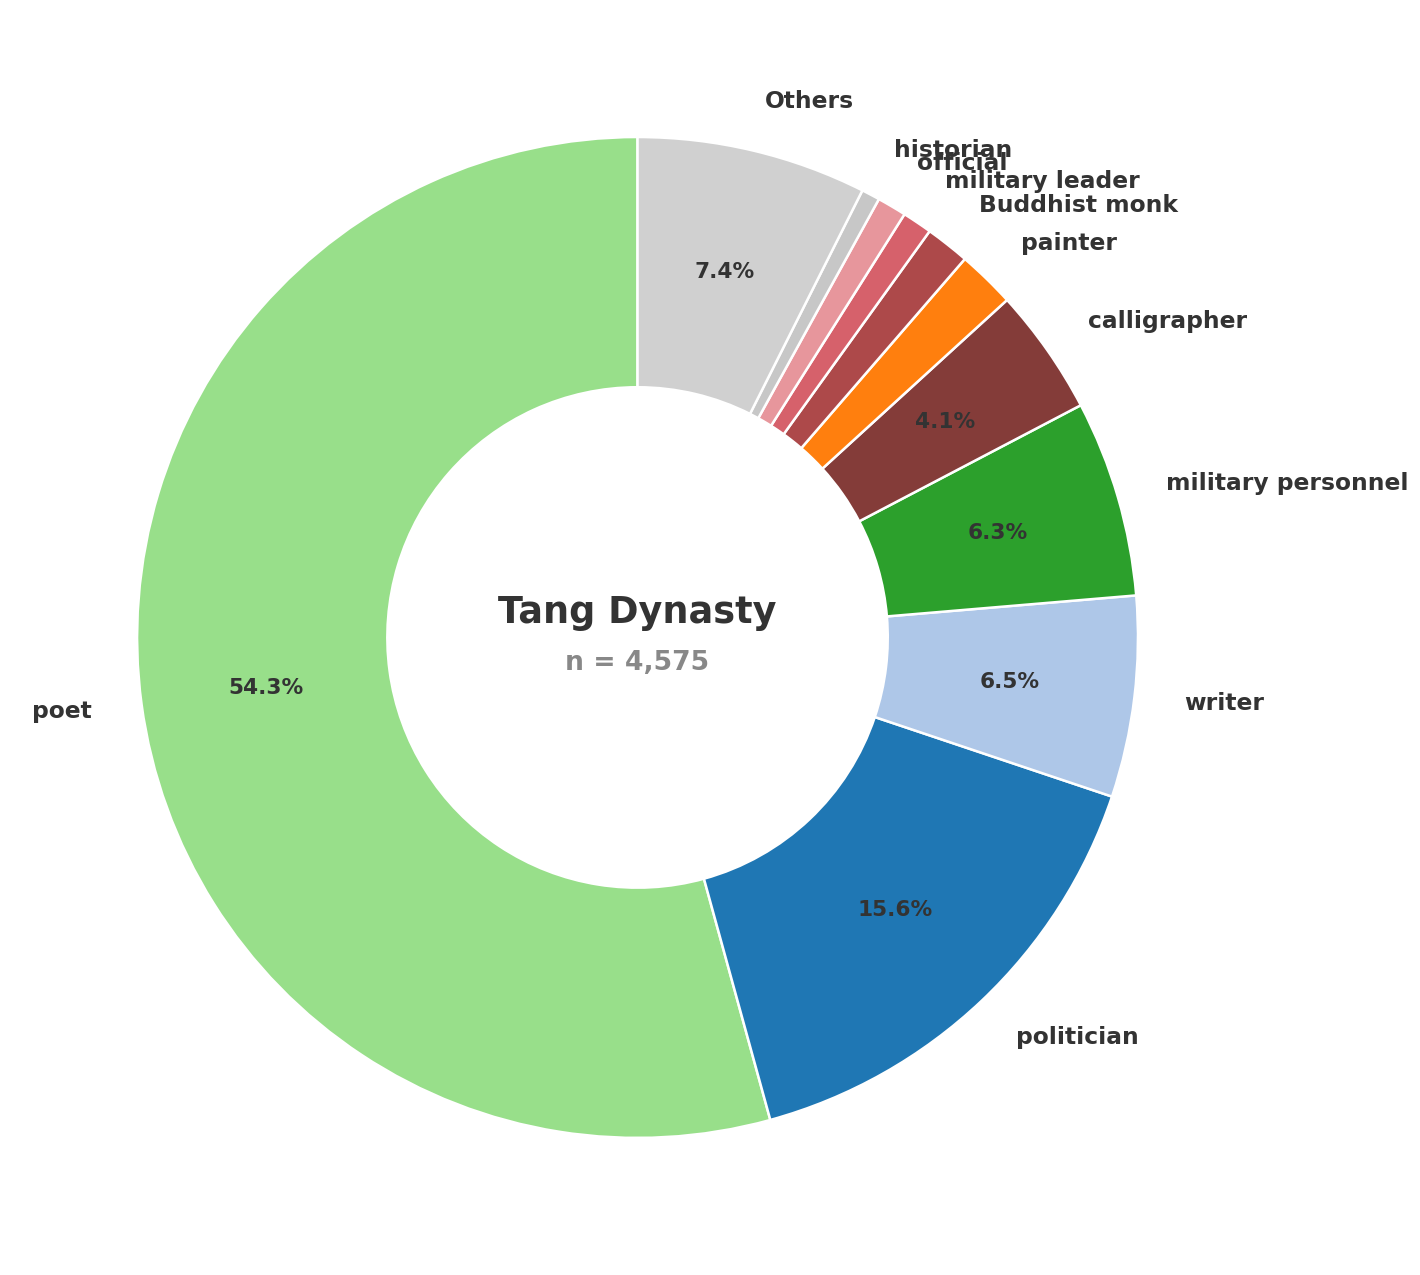

In [15]:
n_before = df_before_1900['wikidata_id'].n_unique()
n_after = df_after_1900['wikidata_id'].n_unique()
n_roman = df_roman_exp['wikidata_id'].n_unique()
n_tang = df_tang_exp['wikidata_id'].n_unique()

draw_donut(labels_before, sizes_before, 'Before 1900', n_individuals=n_before)
draw_donut(labels_after, sizes_after, 'After 1900', n_individuals=n_after)
draw_donut(labels_roman, sizes_roman, 'Roman Empire', n_individuals=n_roman)
draw_donut(labels_tang, sizes_tang, 'Tang Dynasty', n_individuals=n_tang)

## Donut chart -- Roman Empire

In [16]:
# Drawn above with all four charts
pass

## Donut chart -- Tang Dynasty

In [17]:
# Drawn above with all four charts
pass

## Evolution of top occupations per century — stacked bars

For each polity (Roman Empire and Tang Dynasty) we bin individuals by century of `floruit_period_start`, take the **top 10 occupations overall within the polity**, group everything else as *Other*, and plot a non-normalised stacked bar chart so absolute counts are visible.

A single shared colour map is used across both charts: any occupation that appears in either polity's top-10 keeps the same colour in both figures, so it is easy to read across.

For the Roman Empire we restrict to the historical date range (200 BCE – 500 CE) to avoid pulling in *Holy Roman Empire* matches (which share the substring "Roman Empire"). For Tang Dynasty we restrict to 600–1000 CE.

Top 10 occupations - Roman Empire: ['politician', 'military personnel', 'writer', 'Catholic priest', 'presbyter', 'philosopher', 'poet', 'military officer', 'historian', 'priest']
Top 10 occupations - Tang Dynasty: ['poet', 'politician', 'military personnel', 'writer', 'calligrapher', 'painter', 'Buddhist monk', 'official', 'military leader', 'historian']
Shared occupations: ['historian', 'military personnel', 'poet', 'politician', 'writer']


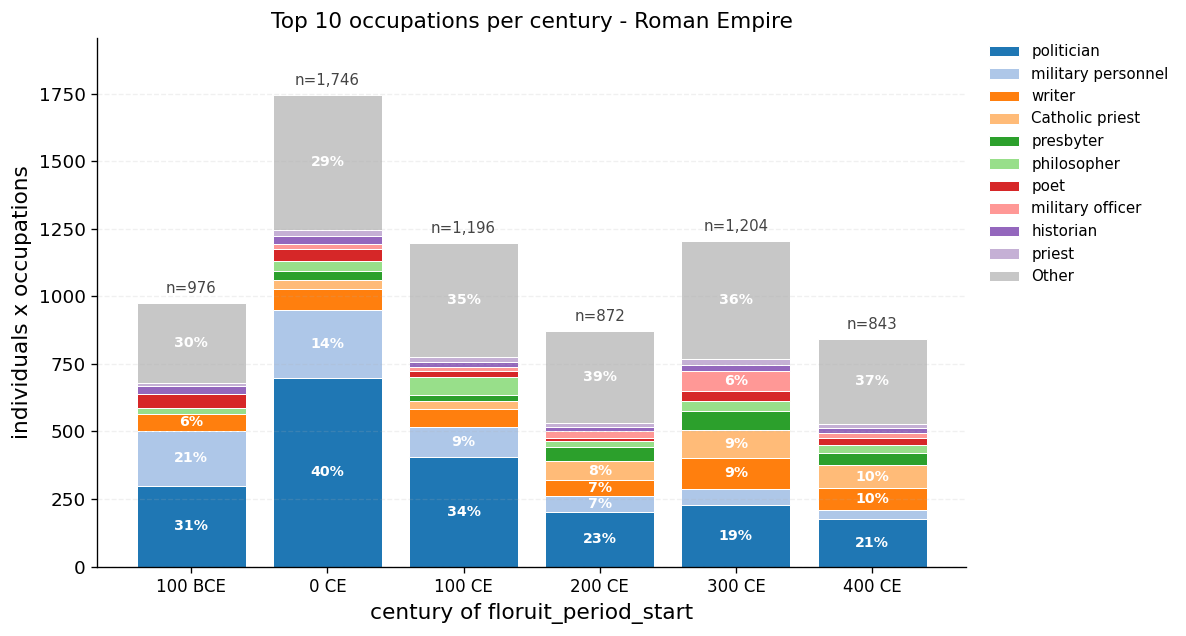

In [18]:
def _top_occupations(df_exp, date_range, n_top):
    lo, hi = date_range
    return (df_exp
            .filter(pl.col('floruit_period_start').is_not_null()
                    & pl.col('floruit_period_start').is_between(lo, hi))
            .group_by('occupation').agg(pl.len().alias('n'))
            .sort('n', descending=True)
            .head(n_top)['occupation'].to_list())


N_TOP_EVOLUTION = 10
ROMAN_RANGE = (-200, 499)
TANG_RANGE = (600, 999)

top_roman = _top_occupations(df_roman_exp, ROMAN_RANGE, N_TOP_EVOLUTION)
top_tang  = _top_occupations(df_tang_exp,  TANG_RANGE,  N_TOP_EVOLUTION)

# unified colour map — union of the two top-10 lists, deterministic order
union_occ = list(dict.fromkeys(top_roman + top_tang))
_palette = list(plt.cm.tab20.colors)
EVO_COLORS = {occ: _palette[i % len(_palette)]
              for i, occ in enumerate(union_occ)}
EVO_COLORS['Other'] = (0.78, 0.78, 0.78)

print(f"Top {N_TOP_EVOLUTION} occupations - Roman Empire: {top_roman}")
print(f"Top {N_TOP_EVOLUTION} occupations - Tang Dynasty: {top_tang}")
print(f"Shared occupations: {sorted(set(top_roman) & set(top_tang))}")


def stacked_evolution(df_exp, polity_label, date_range, top_occ, color_map,
                      label_min_pct=6.0):
    lo, hi = date_range
    d = (df_exp
         .filter(pl.col('floruit_period_start').is_not_null()
                 & pl.col('floruit_period_start').is_between(lo, hi))
         .with_columns(((pl.col('floruit_period_start') // 100) * 100)
                       .alias('century')))

    d = d.with_columns(
        pl.when(pl.col('occupation').is_in(top_occ))
          .then(pl.col('occupation'))
          .otherwise(pl.lit('Other'))
          .alias('occ_grp'))

    pivot = (d.group_by(['century', 'occ_grp'])
               .agg(pl.len().alias('n'))
               .sort('century'))

    centuries = sorted(pivot['century'].unique().to_list())
    occ_order = list(top_occ) + ['Other']
    matrix = {}
    for occ in occ_order:
        row = pivot.filter(pl.col('occ_grp') == occ)
        m = dict(zip(row['century'].to_list(), row['n'].to_list()))
        matrix[occ] = np.array([m.get(c, 0) for c in centuries], dtype=float)

    totals = np.sum([matrix[o] for o in occ_order], axis=0)

    fig, ax = plt.subplots(figsize=(10, 5.4))
    bottom = np.zeros(len(centuries))
    x = np.arange(len(centuries))
    for occ in occ_order:
        vals = matrix[occ]
        ax.bar(x, vals, bottom=bottom, label=occ,
               color=color_map.get(occ, '#aaaaaa'),
               edgecolor='white', lw=0.6, width=0.8)
        # annotate % inside segments large enough to be readable
        for xi, v, b, total in zip(x, vals, bottom, totals):
            if total <= 0 or v <= 0:
                continue
            pct = v / total * 100
            if pct >= label_min_pct:
                ax.text(xi, b + v / 2, f"{pct:.0f}%",
                        ha='center', va='center',
                        fontsize=8.5, color='white', fontweight='bold')
        bottom += vals

    # totals on top of each bar
    for xi, total in zip(x, totals):
        if total > 0:
            ax.text(xi, total + max(totals) * 0.015,
                    f"n={int(total):,}",
                    ha='center', va='bottom',
                    fontsize=9, color='#444')

    def fmt(c):
        return f'{abs(c)} BCE' if c < 0 else f'{c} CE'
    ax.set_xticks(x)
    ax.set_xticklabels([fmt(c) for c in centuries], rotation=0, fontsize=10)
    ax.set_ylabel('individuals x occupations')
    ax.set_xlabel('century of floruit_period_start')
    ax.set_title(f'Top {len(top_occ)} occupations per century - {polity_label}',
                 fontsize=13)
    ax.set_ylim(0, max(totals) * 1.12)
    ax.legend(frameon=False, fontsize=9, loc='upper left',
              bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
    ax.grid(axis='y', alpha=0.18, ls='--')
    plt.tight_layout()
    plt.show()


stacked_evolution(df_roman_exp, 'Roman Empire',
                  date_range=ROMAN_RANGE, top_occ=top_roman,
                  color_map=EVO_COLORS)

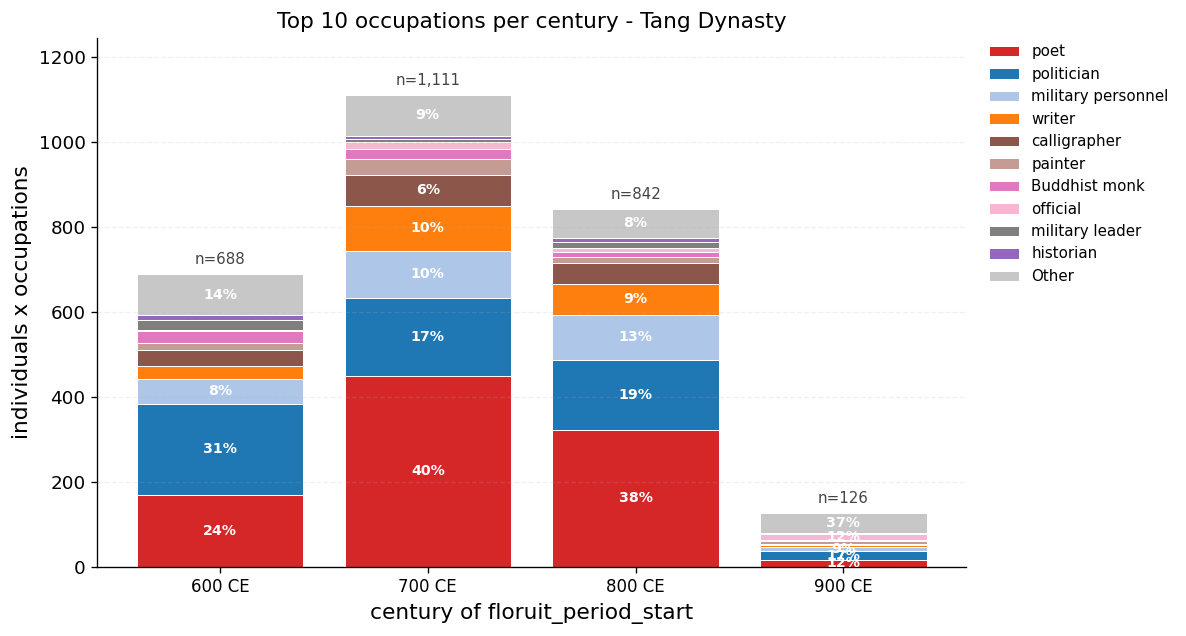

In [19]:
stacked_evolution(df_tang_exp, 'Tang Dynasty',
                  date_range=TANG_RANGE, top_occ=top_tang,
                  color_map=EVO_COLORS)

### Number of unique occupations in the database

In [20]:
n_unique_occ = df_exploded['occupation'].n_unique()
n_unique_roman = df_roman_exp['occupation'].n_unique()
n_unique_tang = df_tang_exp['occupation'].n_unique()
print(f"Unique occupations in the database (with floruit dates): {n_unique_occ:,}")
print(f"Unique occupations attested in Roman Empire cohort:      {n_unique_roman:,}")
print(f"Unique occupations attested in Tang Dynasty cohort:      {n_unique_tang:,}")

Unique occupations in the database (with floruit dates): 17,668
Unique occupations attested in Roman Empire cohort:      1,941
Unique occupations attested in Tang Dynasty cohort:      101


## Clean up

In [21]:
conn.close()